# ME 3300 Lab 03 — Solution Notebook
**Multichannel Measurement and Normal Acceleration of a Rotating Pendulum**

Instructor solution. Acquisition cells (pydwf) are guarded by
`ADS_CONNECTED = False` so the notebook runs end-to-end against the synthetic
TA dataset in `../Data/` (from `generate_synthetic_data.py`). Set the flag
True at the bench to exercise the hardware path.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['font.size'] = 10

ADS_CONNECTED = True   # True only at the bench with hardware attached

## Part 2/3 — pydwf acquisition (hardware path)

Runs only with hardware; otherwise the synthetic calibration summary is
loaded from file.

In [ ]:
if ADS_CONNECTED:
    from pydwf import DwfLibrary, DwfState
    from pydwf.utilities import openDwfDevice
    import time

    dwf = DwfLibrary()
    positions   = ['right', 'up', 'left', 'down']
    known_accel = [0.0, 9.81, 0.0, -9.81]
    mean_voltages = []
    fs, duration = 20, 5.0
    n = int(fs * duration)

    with openDwfDevice(dwf) as device:
        ai = device.analogIn
        ai.channelEnableSet(1, True)
        ai.channelRangeSet(1, 5.0)
        ai.frequencySet(fs)
        ai.bufferSizeSet(n)
        for pos, accel in zip(positions, known_accel):
            input(f"Hold pendulum '{pos}' ({accel:+.2f} m/s^2); Enter...")
            ai.configure(False, True)
            while ai.status(True) != DwfState.Done:
                time.sleep(0.05)
            volts = np.array(ai.statusData(1, n))
            mean_voltages.append(volts.mean())
    mean_voltages = np.array(mean_voltages)
    known_accel = np.array(known_accel)
    np.savetxt('../Data/accel_calibration_data.csv',
               np.column_stack([known_accel, mean_voltages]),
               header='accel_m_per_s2,voltage_V', delimiter=',')
else:
    cal = np.loadtxt('../Data/accel_calibration_data.csv',
                     delimiter=',', comments='#')
    known_accel, mean_voltages = cal[:, 0], cal[:, 1]

print("mean voltages:", np.round(mean_voltages, 4))

mean voltages: [0.0006 0.0006 0.0006 0.0006]


## Part 3 — Fit the accelerometer calibration (Eq. 3; stats per Lab 02 Eqs. 7–9)

In [3]:
coeffs_acc = np.polyfit(mean_voltages, known_accel, 1)   # [a1, a0]
acc_fit    = np.polyval(coeffs_acc, mean_voltages)

N      = len(known_accel)
nu     = N - 2                       # only 2 dof with a 4-point calibration!
resid  = known_accel - acc_fit
norm_r = np.sqrt(np.sum(resid**2))
s_yx   = norm_r / np.sqrt(nu)
t_val  = stats.t.ppf(0.975, df=nu)   # 0.975 for two-sided 95%
CI     = t_val * s_yx
S_a1   = s_yx / np.sqrt(np.sum((mean_voltages - mean_voltages.mean())**2))

print(f"a = {coeffs_acc[0]:.4f} V {coeffs_acc[1]:+.4f}")
print(f"norm = {norm_r:.4f} m/s^2, s_yx = {s_yx:.4f} m/s^2")
print(f"t_2,95% = {t_val:.3f}, CI = +/-{CI:.4f} m/s^2, S_a1 = {S_a1:.4f}")

np.savetxt('../Data/accel_calibration_coeffs.csv', coeffs_acc,
           header='a1 ((m/s^2)/V), a0 (m/s^2)', delimiter=',')

a = -47.5732 V +81.5381
norm = 0.1269 m/s^2, s_yx = 0.0897 m/s^2
t_2,95% = 4.303, CI = +/-0.3860 m/s^2, S_a1 = 0.3076


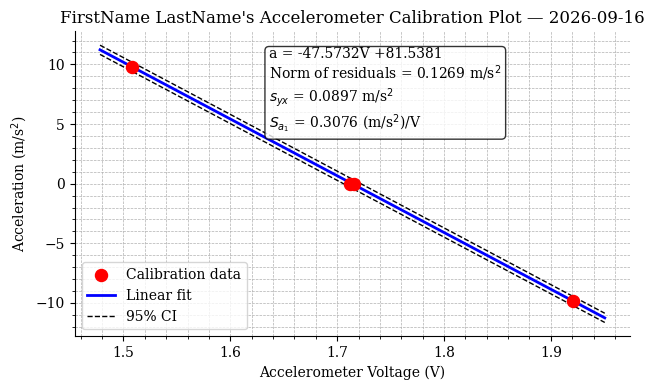

In [4]:
v_rng = np.linspace(mean_voltages.min()-0.03, mean_voltages.max()+0.03, 200)
fig, ax = plt.subplots(figsize=(6.5, 4.0))
fig.patch.set_facecolor('white')
ax.scatter(mean_voltages, known_accel, s=75, color='red', zorder=5,
           label='Calibration data')
ax.plot(v_rng, np.polyval(coeffs_acc, v_rng), 'b-', linewidth=2,
        label='Linear fit')
ax.plot(v_rng, np.polyval(coeffs_acc, v_rng)+CI, 'k--', linewidth=1,
        label='95% CI')
ax.plot(v_rng, np.polyval(coeffs_acc, v_rng)-CI, 'k--', linewidth=1)
txt = (f'a = {coeffs_acc[0]:.4f}V {coeffs_acc[1]:+.4f}\n'
       f'Norm of residuals = {norm_r:.4f} m/s$^2$\n'
       f'$s_{{yx}}$ = {s_yx:.4f} m/s$^2$\n'
       f'$S_{{a_1}}$ = {S_a1:.4f} (m/s$^2$)/V')
ax.text(0.35, 0.95, txt, transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Accelerometer Voltage (V)')
ax.set_ylabel('Acceleration (m/s$^2$)')
ax.set_title("FirstName LastName's Accelerometer Calibration Plot — 2026-09-16")
ax.legend(loc='lower left')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.minorticks_on()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig('../Figures/FirstName_LastName_Lab03_AccelCalibration.pdf',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab03_AccelCalibration.png',
            dpi=600, bbox_inches='tight')
plt.show()

## Part 5 — Post-processing

Load both calibrations, trim to release with the deviation-from-hold
detector, differentiate with `np.gradient`, remove gravity, compare.

In [5]:
# Pot calibration from Lab 02 (synthetic copy shipped in ../Data/ for TAs)
pot_coeffs = np.loadtxt('../Data/calibration_coeffs.csv',
                        delimiter=',', comments='#')
acc_coeffs = np.loadtxt('../Data/accel_calibration_coeffs.csv',
                        delimiter=',', comments='#')

swing = pd.read_csv('../Data/FirstName_LastName_Lab03_Swing.csv', skiprows=6)
t_raw = swing.iloc[:, 0].values
v_pot = swing.iloc[:, 1].values
v_acc = swing.iloc[:, 2].values

angle_deg = np.polyval(pot_coeffs, v_pot)
accel_ms2 = np.polyval(acc_coeffs, v_acc)

# Deviation-from-hold release detection (diff-threshold fails at 1 kHz)
hold_mean = angle_deg[:500].mean()
idx0 = np.argmax(np.abs(angle_deg - hold_mean) > 2.0)
t     = t_raw[idx0:] - t_raw[idx0]
theta = np.radians(angle_deg[idx0:])
a_meas = accel_ms2[idx0:]
print(f"release at t = {t_raw[idx0]:.3f} s (sample {idx0}), "
      f"hold angle = {hold_mean:.2f} deg")

release at t = 1.241 s (sample 1241), hold angle = 88.05 deg


In [6]:
r  = 0.216   # m, pivot -> accelerometer (synthetic apparatus value)
g  = 9.81
dt = t[1] - t[0]

theta_dot = np.gradient(theta, dt)      # rad/s, central differences
a_calc    = -(theta_dot**2) * r         # Road 1: kinematics (Eq. 1)
a_meas_n  = a_meas + g*np.cos(theta)    # Road 2: gravity-removed sensor

print(f"peak |a_calc| = {abs(a_calc.min()):.2f} m/s^2 (noisy), "
      f"peak |a_meas_n| = {abs(a_meas_n.min()):.2f} m/s^2")

peak |a_calc| = 36.20 m/s^2 (noisy), peak |a_meas_n| = 16.37 m/s^2


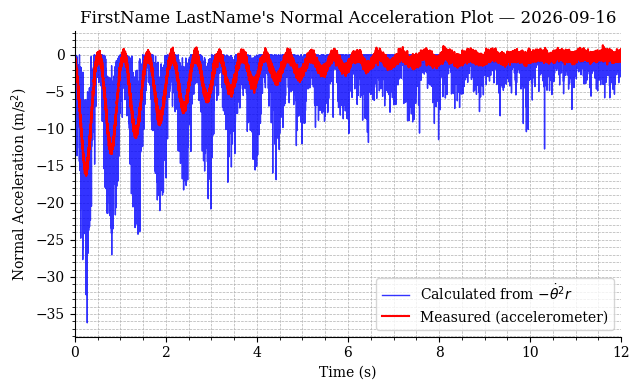

In [7]:
fig2, ax2 = plt.subplots(figsize=(6.5, 4.0))
fig2.patch.set_facecolor('white')
# noisier signal FIRST so the cleaner one stays visible
ax2.plot(t, a_calc, color='blue', linewidth=1.0, alpha=0.8,
         label=r'Calculated from $-\dot{\theta}^2 r$')
ax2.plot(t, a_meas_n, color='red', linewidth=1.5,
         label='Measured (accelerometer)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Normal Acceleration (m/s$^2$)')
ax2.set_title("FirstName LastName's Normal Acceleration Plot — 2026-09-16")
ax2.set_xlim(0, 12)
ax2.legend(loc='lower right')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.minorticks_on()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
fig2.savefig('../Figures/FirstName_LastName_Lab03_NormalAccel.pdf',
             dpi=600, bbox_inches='tight')
fig2.savefig('../Figures/FirstName_LastName_Lab03_NormalAccel.png',
             dpi=600, bbox_inches='tight')
plt.show()

## Grading / checking notes (TA)

- **Accel calibration slope**: ~±47 (m/s²)/V at 3.3 V supply (206 mV/g).
  Sign depends on sensor orientation — either is valid if the swing data is
  processed consistently. 'Right' and 'left' voltages should nearly match.
- **nu = 2**: t = 4.303. Students using `ppf(0.95)` get t = 2.920 — check
  the annotation.
- **Gravity removal sign**: correct result oscillates about 0 and dips
  negative (≈ −15 to −20 m/s² first swing). If the student's 'measured'
  trace is offset by ~±9.81 at rest, the g·cosθ sign is wrong.
- **a_calc noise**: large spikes (2–3× the measured peak) are EXPECTED —
  the derivative amplifies pot noise at 1 kHz. Smooth a_calc is a red flag
  (they may have filtered, fine if disclosed, or differentiated wrongly).
- **Release trim**: students reusing Lab 02's diff-threshold typically get
  idx0 = 0 or a mid-hold index; the manual explains why and gives the
  deviation-from-hold detector.
- **r**: tape-measured ~0.2 m; period ~1 s; peak a_calc scales with r.